In [2]:
!pip install transformers==4.40.0 torchaudio kagglehub soundfile scikit-learn -q

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=memory.total,memory.free',
                        '--format=csv,noheader'], capture_output=True, text=True)
print(f"GPU Memory: {result.stdout.strip()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15360 MiB, 14910 MiB


VCTK data

In [3]:
import os
import kagglehub

path = kagglehub.dataset_download("pratt3000/vctk-corpus")
print(f"Dataset path: {path}")

print("\nTop-level contents:")
for item in sorted(os.listdir(path)):
    full = os.path.join(path, item)
    if os.path.isdir(full):
        n = len(os.listdir(full))
        print(f"  DIR:  {item}/  ({n} items)")
    else:
        size = os.path.getsize(full) / 1024**2
        print(f"  FILE: {item}  ({size:.1f} MB)")

print("\nSearching for speaker folders:")
audio_root = None
for root, dirs, files_ in os.walk(path):
    spk_dirs = [d for d in dirs if d.startswith('p') and d[1:].isdigit()]
    if len(spk_dirs) > 5:
        audio_root = root
        print(f"  Audio root : {root}")
        print(f"  Speakers   : {len(spk_dirs)}")
        print(f"  Examples   : {sorted(spk_dirs)[:8]}")
        break

if audio_root is None:
    print("Could not find speaker dirs, paste full output and I will fix")
else:
    print(f"\nAUDIO_ROOT = '{audio_root}'")
    first_spk = sorted([d for d in os.listdir(audio_root)
                        if d.startswith('p') and d[1:].isdigit()])[0]
    spk_path = os.path.join(audio_root, first_spk)
    sample_files = os.listdir(spk_path)[:5]
    print(f"\nSample files in {first_spk}/:")
    for f in sample_files:
        print(f"  {f}")

100%|██████████| 10.4G/10.4G [01:49<00:00, 102MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1

Top-level contents:
  FILE: README.txt  (0.0 MB)
  DIR:  VCTK-Corpus/  (1 items)
  FILE: license_text  (0.0 MB)

Searching for speaker folders:
  Audio root : /root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1/VCTK-Corpus/VCTK-Corpus/txt
  Speakers   : 108
  Examples   : ['p225', 'p226', 'p227', 'p228', 'p229', 'p230', 'p231', 'p232']

AUDIO_ROOT = '/root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1/VCTK-Corpus/VCTK-Corpus/txt'

Sample files in p225/:
  p225_191.txt
  p225_002.txt
  p225_009.txt
  p225_008.txt
  p225_299.txt


In [4]:
path = kagglehub.dataset_download("pratt3000/vctk-corpus")
print(path)

/root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1


Explore the structure

In [6]:
import os

base = "/root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1"

for root, dirs, files in os.walk(base):
    print(root)
    break

/root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1


In [7]:
for root, dirs, files in os.walk(base):
    print("\nDIR:", root)
    print("SUBDIRS:", dirs[:5])
    print("FILES:", files[:5])
    break


DIR: /root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1
SUBDIRS: ['VCTK-Corpus']
FILES: ['license_text', 'README.txt']


In [8]:
import os

base = "/root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1"

print("Full directory tree (searching for audio)...")
audio_root = None

for root, dirs, files_ in os.walk(base):
    audio = [f for f in files_ if f.endswith('.wav') or f.endswith('.flac')]
    if audio:
        print(f"\nFound audio at: {root}")
        print(f"Sample files  : {audio[:4]}")
        print(f"Total files   : {len(audio)}")
        audio_root = root
        break

    depth = root.replace(base, '').count(os.sep)
    if depth <= 3:
        indent = '  ' * depth
        print(f"{indent}{os.path.basename(root)}/")

print(f"\nAUDIO_ROOT = '{audio_root}'")

Full directory tree (searching for audio)...
1/
  VCTK-Corpus/
    VCTK-Corpus/
      txt/
      wav48/

Found audio at: /root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1/VCTK-Corpus/VCTK-Corpus/wav48/p300
Sample files  : ['p300_017.wav', 'p300_138.wav', 'p300_275.wav', 'p300_301.wav']
Total files   : 399

AUDIO_ROOT = '/root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1/VCTK-Corpus/VCTK-Corpus/wav48/p300'


correct audio root

In [9]:
import os

AUDIO_ROOT = "/root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1/VCTK-Corpus/VCTK-Corpus/wav48/"

# List all speaker folders
spk_dirs = sorted([d for d in os.listdir(AUDIO_ROOT)
                   if os.path.isdir(os.path.join(AUDIO_ROOT, d))
                   and d.startswith('p') and d[1:].isdigit()])

print(f"Total speakers found : {len(spk_dirs)}")
print(f"First 8 speakers     : {spk_dirs[:8]}")
print(f"Last 8 speakers      : {spk_dirs[-8:]}")

print("\nFiles per speaker (sample):")
for spk in spk_dirs[:5]:
    spk_path = os.path.join(AUDIO_ROOT, spk)
    wavs = [f for f in os.listdir(spk_path) if f.endswith('.wav')]
    print(f"  {spk}: {len(wavs)} wav files")

# Check one wav file is loadable
import torchaudio
sample_wav = os.path.join(AUDIO_ROOT, spk_dirs[0],
                          os.listdir(os.path.join(AUDIO_ROOT, spk_dirs[0]))[0])
waveform, sr = torchaudio.load(sample_wav)
print(f"\nSample WAV check:")
print(f"  Path       : {sample_wav}")
print(f"  Shape      : {waveform.shape}")
print(f"  Sample rate: {sr}")
print(f"  Duration   : {waveform.shape[1]/sr:.2f} sec")

print(f"\nAUDIO_ROOT confirmed = '{AUDIO_ROOT}'")

Total speakers found : 109
First 8 speakers     : ['p225', 'p226', 'p227', 'p228', 'p229', 'p230', 'p231', 'p232']
Last 8 speakers      : ['p351', 'p360', 'p361', 'p362', 'p363', 'p364', 'p374', 'p376']

Files per speaker (sample):
  p225: 231 wav files
  p226: 356 wav files
  p227: 389 wav files
  p228: 366 wav files
  p229: 379 wav files

Sample WAV check:
  Path       : /root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1/VCTK-Corpus/VCTK-Corpus/wav48/p225/p225_089.wav
  Shape      : torch.Size([1, 172267])
  Sample rate: 48000
  Duration   : 3.59 sec

AUDIO_ROOT confirmed = '/root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1/VCTK-Corpus/VCTK-Corpus/wav48/'


In [10]:
import os, random, numpy as np
import torch
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

class Config:
    # Paths
    AUDIO_ROOT     = "/root/.cache/kagglehub/datasets/pratt3000/vctk-corpus/versions/1/VCTK-Corpus/VCTK-Corpus/wav48/"
    CHECKPOINT_DIR = "/content/checkpoints"
    LOG_DIR        = "/content/logs"

    # Dataset
    MAX_SPEAKERS          = 109
    MAX_SAMPLES_PER_SPEAKER = 60
    SAMPLE_RATE           = 16000 # resample from 48k → 16k (matches HuBERT)
    MAX_AUDIO_SECS        = 3.0   # crop/pad to 3 seconds
    MAX_AUDIO_SAMPLES     = int(3.0 * 16000)  # = 48000 samples

    # Model
    BACKBONE          = "facebook/hubert-base-ls960"
    FREEZE_BACKBONE   = True
    EMBED_DIM         = 768       # HuBERT hidden size
    SPEAKER_EMBED_DIM = 256

    # Unlearning
    N_FORGET_SPEAKERS = 2         # 2 out of 10 speakers will be forgotten
    GRL_ALPHA_MAX     = 1.5
    GRL_WARMUP_STEPS  = 500

    # Training
    BATCH_SIZE    = 8
    LR_HEAD       = 5e-4
    PHASE1_EPOCHS = 10
    PHASE2_EPOCHS = 15
    DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

CFG = Config()
os.makedirs(CFG.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(CFG.LOG_DIR, exist_ok=True)
print(f"Device : {CFG.DEVICE}")
print(f"Config : {CFG.MAX_SPEAKERS} speakers, "
      f"{CFG.MAX_SAMPLES_PER_SPEAKER} samples each, "
      f"{CFG.MAX_AUDIO_SECS}s audio")


# ── Dataset Class ──────────────────────────────────────────────────────────
class VCTKDataset(Dataset):
    def __init__(self, samples, speaker2idx, augment=False):
        """
        samples     : list of (wav_path, speaker_id_str)
        speaker2idx : dict mapping speaker str → int label
        augment     : apply time masking (only for training)
        """
        self.samples     = samples
        self.speaker2idx = speaker2idx
        self.augment     = augment
        self.resampler   = T.Resample(orig_freq=48000, new_freq=CFG.SAMPLE_RATE)

    def __len__(self):
        return len(self.samples)

    def _load(self, path):
        waveform, sr = torchaudio.load(path)

        # Mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(0, keepdim=True)

        # Resample 48k → 16k
        waveform = self.resampler(waveform)   # (1, T)
        waveform = waveform.squeeze(0)        # (T,)

        # Crop or pad to fixed length
        L = CFG.MAX_AUDIO_SAMPLES
        if waveform.shape[0] > L:
            start    = random.randint(0, waveform.shape[0] - L)
            waveform = waveform[start : start + L]
        else:
            waveform = F.pad(waveform, (0, L - waveform.shape[0]))

        # Normalize
        waveform = (waveform - waveform.mean()) / (waveform.std() + 1e-8)
        return waveform

    def __getitem__(self, idx):
        path, spk_str = self.samples[idx]
        waveform      = self._load(path)
        label         = self.speaker2idx[spk_str]
        return waveform, label, spk_str


# ── Build datasets ─────────────────────────────────────────────────────────
def build_datasets():
    # Collect files
    all_spk = sorted([d for d in os.listdir(CFG.AUDIO_ROOT)
                      if os.path.isdir(os.path.join(CFG.AUDIO_ROOT, d))
                      and d.startswith('p') and d[1:].isdigit()])

    # Limit to MAX_SPEAKERS
    all_spk = all_spk[:CFG.MAX_SPEAKERS]
    print(f"Using speakers: {all_spk}")

    # Build (path, speaker) list
    samples = []
    for spk in all_spk:
        spk_dir = os.path.join(CFG.AUDIO_ROOT, spk)
        wavs    = sorted([f for f in os.listdir(spk_dir) if f.endswith('.wav')])
        wavs    = wavs[:CFG.MAX_SAMPLES_PER_SPEAKER]
        for w in wavs:
            samples.append((os.path.join(spk_dir, w), spk))

    print(f"Total samples    : {len(samples)}")

    # Speaker mappings
    speaker2idx = {spk: i for i, spk in enumerate(all_spk)}
    idx2speaker = {i: spk for spk, i in speaker2idx.items()}
    CFG.NUM_SPEAKERS = len(all_spk)

    # Forget / Retain split
    forget_spks = set(all_spk[:CFG.N_FORGET_SPEAKERS])   # first 2 = forget
    retain_spks = set(all_spk) - forget_spks
    print(f"Forget speakers  : {sorted(forget_spks)}")
    print(f"Retain speakers  : {sorted(retain_spks)}")

    # Train / val / test split (stratified by speaker)
    train_s, temp_s = train_test_split(samples, test_size=0.2,
                                       random_state=SEED,
                                       stratify=[s[1] for s in samples])
    val_s, test_s   = train_test_split(temp_s,  test_size=0.5,
                                       random_state=SEED,
                                       stratify=[s[1] for s in temp_s])

    # Datasets
    train_ds  = VCTKDataset(train_s, speaker2idx, augment=True)
    val_ds    = VCTKDataset(val_s,   speaker2idx, augment=False)
    test_ds   = VCTKDataset(test_s,  speaker2idx, augment=False)

    # Forget / retain eval sets (from test)
    forget_test = [(p, s) for p, s in test_s if s in forget_spks]
    retain_test = [(p, s) for p, s in test_s if s in retain_spks]
    forget_ds   = VCTKDataset(forget_test, speaker2idx)
    retain_ds   = VCTKDataset(retain_test, speaker2idx)

    print(f"\nSplit sizes:")
    print(f"  Train  : {len(train_ds)}")
    print(f"  Val    : {len(val_ds)}")
    print(f"  Test   : {len(test_ds)}")
    print(f"  Forget : {len(forget_ds)}")
    print(f"  Retain : {len(retain_ds)}")

    return (train_ds, val_ds, test_ds, forget_ds, retain_ds,
            speaker2idx, idx2speaker, forget_spks, retain_spks)


# ── Run it ─────────────────────────────────────────────────────────────────
(train_ds, val_ds, test_ds, forget_ds, retain_ds,
 speaker2idx, idx2speaker, forget_spks, retain_spks) = build_datasets()

# ── Quick sanity check ─────────────────────────────────────────────────────
waveform, label, spk = train_ds[0]
print(f"\nSanity check:")
print(f"  Waveform shape : {waveform.shape}  (expect: torch.Size([48000]))")
print(f"  Label          : {label}  ({spk})")
print(f"  Min/Max        : {waveform.min():.3f} / {waveform.max():.3f}")

Device : cuda
Config : 109 speakers, 60 samples each, 3.0s audio
Using speakers: ['p225', 'p226', 'p227', 'p228', 'p229', 'p230', 'p231', 'p232', 'p233', 'p234', 'p236', 'p237', 'p238', 'p239', 'p240', 'p241', 'p243', 'p244', 'p245', 'p246', 'p247', 'p248', 'p249', 'p250', 'p251', 'p252', 'p253', 'p254', 'p255', 'p256', 'p257', 'p258', 'p259', 'p260', 'p261', 'p262', 'p263', 'p264', 'p265', 'p266', 'p267', 'p268', 'p269', 'p270', 'p271', 'p272', 'p273', 'p274', 'p275', 'p276', 'p277', 'p278', 'p279', 'p280', 'p281', 'p282', 'p283', 'p284', 'p285', 'p286', 'p287', 'p288', 'p292', 'p293', 'p294', 'p295', 'p297', 'p298', 'p299', 'p300', 'p301', 'p302', 'p303', 'p304', 'p305', 'p306', 'p307', 'p308', 'p310', 'p311', 'p312', 'p313', 'p314', 'p315', 'p316', 'p317', 'p318', 'p323', 'p326', 'p329', 'p330', 'p333', 'p334', 'p335', 'p336', 'p339', 'p340', 'p341', 'p343', 'p345', 'p347', 'p351', 'p360', 'p361', 'p362', 'p363', 'p364', 'p374', 'p376']
Total samples    : 6540
Forget speakers  : ['p

Model Architecture

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from transformers import HubertModel

class GRLFunction(Function):
    """
    Forward  : identity (passes input unchanged)
    Backward : multiplies gradient by -alpha
    Effect   : forces upstream layers to LOSE speaker information
    """
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.save_for_backward(alpha)
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        alpha, = ctx.saved_tensors
        return -alpha * grad_output, None

class GradientReversalLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha = torch.tensor(0.0)

    def set_alpha(self, val):
        self.alpha = torch.tensor(val, dtype=torch.float32)

    def forward(self, x):
        return GRLFunction.apply(x, self.alpha.to(x.device))


class AttentiveStatsPool(nn.Module):
    """
    Converts (B, T, D) sequence → (B, 2D) summary vector
    Uses learned attention to weight frames, then returns
    weighted mean + weighted std concatenated.
    """
    def __init__(self, in_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (B, T, D)
        w = torch.softmax(self.attn(x), dim=1)   # (B, T, 1)
        mean = (w * x).sum(dim=1)                 # (B, D)
        var  = (w * (x - mean.unsqueeze(1))**2).sum(dim=1)
        std  = torch.sqrt(var + 1e-8)             # (B, D)
        return torch.cat([mean, std], dim=-1)     # (B, 2D)


class SpeakerEncoder(nn.Module):
    """
    HuBERT hidden states → speaker embedding → speaker logits
    Used for both Phase 1 (classification) and evaluation.
    """
    def __init__(self, in_dim, embed_dim, num_speakers):
        super().__init__()
        self.pool = AttentiveStatsPool(in_dim)
        self.proj = nn.Sequential(
            nn.Linear(in_dim * 2, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU()
        )
        self.classifier = nn.Linear(embed_dim, num_speakers)

    def forward(self, hidden, return_embedding=False):
        pooled    = self.pool(hidden)          # (B, 2D)
        embedding = self.proj(pooled)          # (B, embed_dim)
        logits    = self.classifier(embedding) # (B, num_speakers)
        if return_embedding:
            return logits, embedding
        return logits


class ContentEncoder(nn.Module):
    """
    Preserves phonetic (speech content) information.
    Trained with MSE loss against original HuBERT features.
    Ensures WER does not degrade after unlearning.
    """
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Linear(dim, dim)
        )

    def forward(self, x):
        return self.net(x)   # (B, T, D)


class AdversarialSpeakerHead(nn.Module):
    """
    Sits after the GRL.
    Tries to classify speaker → but GRL flips gradients →
    backbone is forced to remove speaker info.
    """
    def __init__(self, in_dim, num_speakers):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.mlp  = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_speakers)
        )

    def forward(self, x):
        # x: (B, T, D)
        pooled = x.mean(dim=1)
        return self.mlp(pooled)

# ── 4.6 Full Model ─────────────────────────────────────────────────────────
class SpeakerUnlearningModel(nn.Module):
    """
    Full pipeline:
      Raw Audio (16kHz)
          ↓
      HuBERT backbone (frozen)
          ↓
      Hidden states (B, T, 768)
         ↙              ↘
    ContentEncoder    SpeakerEncoder → logits
    (phonetic)             ↓
                      GRL (Phase 2 only)
                           ↓
                      AdversarialHead → adv_logits
    """
    def __init__(self, num_speakers):
        super().__init__()

        # SSL Backbone
        print("Loading HuBERT backbone...")
        self.backbone = HubertModel.from_pretrained(CFG.BACKBONE)
        if CFG.FREEZE_BACKBONE:
            for p in self.backbone.parameters():
                p.requires_grad = False
            print("Backbone frozen (saves ~12GB VRAM on T4)")
        for layer in self.backbone.encoder.layers[-2:]:
          for p in layer.parameters():
             p.requires_grad = True
        print("Last 2 HuBERT layers unfrozen for fine-tuning")
        D = CFG.EMBED_DIM  # 768

        # Heads
        self.content_encoder  = ContentEncoder(D)
        self.speaker_encoder  = SpeakerEncoder(D, CFG.SPEAKER_EMBED_DIM, num_speakers)
        self.grl              = GradientReversalLayer()
        self.adv_head         = AdversarialSpeakerHead(D, num_speakers)

    def get_hidden(self, waveforms):
        """Extract HuBERT features — called in all modes."""
        with torch.no_grad() if CFG.FREEZE_BACKBONE else torch.enable_grad():
            out = self.backbone(waveforms)
        return out.last_hidden_state   # (B, T, 768)

    def forward(self, waveforms, mode="classify"):
        hidden = self.get_hidden(waveforms)   # (B, T, 768)

        if mode == "classify":
            # Phase 1: just classify speaker
            spk_logits  = self.speaker_encoder(hidden)
            content_out = self.content_encoder(hidden)
            return spk_logits, content_out, hidden

        elif mode == "unlearn":
            # Phase 2: adversarial unlearning
            spk_logits  = self.speaker_encoder(hidden)
            content_out = self.content_encoder(hidden)
            # GRL path — gradient is REVERSED here
            hidden_rev  = self.grl(hidden)
            adv_logits  = self.adv_head(hidden_rev)
            return spk_logits, adv_logits, content_out, hidden

        elif mode == "eval":
            # Evaluation: just speaker logits
            return self.speaker_encoder(hidden)


# ── Build model ────────────────────────────────────────────────────────────
model = SpeakerUnlearningModel(num_speakers=CFG.NUM_SPEAKERS).to(CFG.DEVICE)

# Parameter count
total     = sum(p.numel() for p in model.parameters()) / 1e6
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"\nTotal params     : {total:.1f}M")
print(f"Trainable params : {trainable:.1f}M  (heads only, backbone frozen)")

# ── Quick forward pass test ────────────────────────────────────────────────
print("\nRunning forward pass test...")
dummy = torch.randn(2, CFG.MAX_AUDIO_SAMPLES).to(CFG.DEVICE)

with torch.no_grad():
    spk_logits, content_out, hidden = model(dummy, mode="classify")

print(f"  Input shape    : {dummy.shape}")
print(f"  Hidden shape   : {hidden.shape}      (B, T, 768)")
print(f"  Speaker logits : {spk_logits.shape}  (B, num_speakers)")
print(f"  Content out    : {content_out.shape} (B, T, 768)")

Loading HuBERT backbone...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/hubert-base-ls960 were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for pre

Backbone frozen (saves ~12GB VRAM on T4)
Last 2 HuBERT layers unfrozen for fine-tuning

Total params     : 96.4M
Trainable params : 16.2M  (heads only, backbone frozen)

Running forward pass test...
  Input shape    : torch.Size([2, 48000])
  Hidden shape   : torch.Size([2, 149, 768])      (B, T, 768)
  Speaker logits : torch.Size([2, 109])  (B, num_speakers)
  Content out    : torch.Size([2, 149, 768]) (B, T, 768)


In [12]:
# CELL 5: Phase 1 Training — Baseline Speaker Classification
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import defaultdict
from sklearn.metrics import accuracy_score
import time

# ── DataLoaders ────────────────────────────────────────────────────────────
train_dl  = DataLoader(train_ds,  batch_size=CFG.BATCH_SIZE, shuffle=True,
                       num_workers=2, pin_memory=True)
val_dl    = DataLoader(val_ds,    batch_size=CFG.BATCH_SIZE, shuffle=False,
                       num_workers=2, pin_memory=True)
test_dl   = DataLoader(test_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False,
                       num_workers=2, pin_memory=True)
forget_dl = DataLoader(forget_ds, batch_size=CFG.BATCH_SIZE, shuffle=False)
retain_dl = DataLoader(retain_ds, batch_size=CFG.BATCH_SIZE, shuffle=False)

print(f"Train batches  : {len(train_dl)}")
print(f"Val batches    : {len(val_dl)}")


# ── Loss & Optimizer ───────────────────────────────────────────────────────
ce_loss   = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW([
    {'params': model.speaker_encoder.parameters(), 'lr': CFG.LR_HEAD},
    {'params': model.content_encoder.parameters(), 'lr': CFG.LR_HEAD * 0.1},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.PHASE1_EPOCHS, eta_min=1e-5
)


# ── Eval helper ───────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(dataloader):
    model.eval()
    all_preds, all_labels = [], []
    for waveforms, labels, _ in dataloader:
        waveforms = waveforms.to(CFG.DEVICE)
        logits    = model(waveforms, mode="eval")
        preds     = logits.argmax(-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return accuracy_score(all_labels, all_preds)


# ── Training loop ──────────────────────────────────────────────────────────
phase1_history = defaultdict(list)

print("\n" + "="*55)
print("PHASE 1: Baseline Speaker Classification")
print("="*55)
print(f"{'Epoch':<7} {'Loss':<10} {'Train Acc':<12} {'Val Acc':<10} {'Time'}")
print("-"*55)

best_val_acc = 0.0

for epoch in range(CFG.PHASE1_EPOCHS):
    model.train()
    t0 = time.time()
    total_loss, correct, total = 0.0, 0, 0

    for waveforms, labels, _ in train_dl:
        waveforms = waveforms.to(CFG.DEVICE)
        labels    = labels.to(CFG.DEVICE)

        optimizer.zero_grad()

        spk_logits, content_out, hidden = model(waveforms, mode="classify")

        # Speaker classification loss
        loss_cls = ce_loss(spk_logits, labels)

        # Content preservation loss (keep phonetic info intact)
        loss_content = F.mse_loss(content_out, hidden.detach())

        loss = loss_cls + 0.1 * loss_content
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss_cls.item()
        correct    += (spk_logits.argmax(-1) == labels).sum().item()
        total      += labels.size(0)

    scheduler.step()

    train_acc = correct / total
    val_acc   = evaluate(val_dl)
    elapsed   = time.time() - t0

    phase1_history['loss'].append(total_loss / len(train_dl))
    phase1_history['train_acc'].append(train_acc)
    phase1_history['val_acc'].append(val_acc)

    print(f"  {epoch+1:<5} {total_loss/len(train_dl):<10.4f} "
          f"{train_acc*100:<12.1f} {val_acc*100:<10.1f} {elapsed:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   f"{CFG.CHECKPOINT_DIR}/phase1_best.pt")
        print(f"          >>> Saved best model (val={val_acc*100:.1f}%)")

# Load best checkpoint
model.load_state_dict(torch.load(f"{CFG.CHECKPOINT_DIR}/phase1_best.pt"))
print(f"\nPhase 1 done. Best val acc: {best_val_acc*100:.1f}%")

# ── Before-unlearning snapshot ────────────────────────────────────────────
print("\n--- Accuracy BEFORE Unlearning ---")
forget_acc_before = evaluate(forget_dl)
retain_acc_before = evaluate(retain_dl)
test_acc_before   = evaluate(test_dl)
print(f"  Overall  : {test_acc_before*100:.1f}%")
print(f"  Forget   : {forget_acc_before*100:.1f}%  (target: <10% after unlearning)")
print(f"  Retain   : {retain_acc_before*100:.1f}%  (target: stays high)")

Train batches  : 654
Val batches    : 82

PHASE 1: Baseline Speaker Classification
Epoch   Loss       Train Acc    Val Acc    Time
-------------------------------------------------------
  1     3.7892     14.6         50.6       153.5s
          >>> Saved best model (val=50.6%)
  2     1.8376     53.5         71.9       121.2s
          >>> Saved best model (val=71.9%)
  3     1.1210     68.8         80.9       119.8s
          >>> Saved best model (val=80.9%)
  4     0.8573     75.6         87.0       120.0s
          >>> Saved best model (val=87.0%)
  5     0.7029     79.0         86.5       119.1s
  6     0.5845     82.9         90.4       120.9s
          >>> Saved best model (val=90.4%)
  7     0.4938     85.5         93.0       120.0s
          >>> Saved best model (val=93.0%)
  8     0.4535     86.2         93.1       122.8s
          >>> Saved best model (val=93.1%)
  9     0.4062     88.6         92.0       121.2s
  10    0.3785     88.8         93.3       120.7s
          >>

In [13]:
# CELL 6: Phase 2 — Selective Speaker Identity Unlearning
import numpy as np
from collections import defaultdict
import time

# ── Forget speaker indices ─────────────────────────────────────────────────
forget_idxs = set(speaker2idx[s] for s in forget_spks)
retain_idxs = set(speaker2idx[s] for s in retain_spks)
print(f"Forget label indices : {forget_idxs}  → speakers {sorted(forget_spks)}")
print(f"Retain label indices : {retain_idxs}")

# ── Optimizer for Phase 2 ──────────────────────────────────────────────────
# Only train the heads — backbone stays frozen
optimizer2 = torch.optim.AdamW([
    {'params': model.speaker_encoder.parameters(),  'lr': CFG.LR_HEAD},
    {'params': model.adv_head.parameters(),          'lr': CFG.LR_HEAD},
    {'params': model.content_encoder.parameters(),   'lr': CFG.LR_HEAD * 0.1},
    # Naya — unfrozen backbone layers
    {'params': model.backbone.encoder.layers[-1].parameters(), 'lr': 1e-5},
    {'params': model.backbone.encoder.layers[-2].parameters(), 'lr': 5e-6},
], weight_decay=1e-4)

scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=CFG.PHASE2_EPOCHS, eta_min=1e-5
)

# ── GRL alpha schedule ─────────────────────────────────────────────────────
def get_grl_alpha(step, warmup=CFG.GRL_WARMUP_STEPS, max_alpha=CFG.GRL_ALPHA_MAX):
    """Sigmoid ramp: 0 → max_alpha over warmup steps. Prevents training instability."""
    p     = min(step / warmup, 1.0)
    alpha = max_alpha * (2.0 / (1.0 + np.exp(-10 * p)) - 1.0)
    return alpha

# ── Phase 2 training loop ──────────────────────────────────────────────────
phase2_history = defaultdict(list)
global_step    = 0
best_score     = float('inf')   # lower = better (forget_acc - retain_acc)

print("\n" + "="*65)
print("PHASE 2: Selective Speaker Identity Unlearning")
print("="*65)
print(f"{'Ep':<4} {'Loss':<8} {'α':<6} {'F-Acc(train)':<14} "
      f"{'Forget Acc':<12} {'Retain Acc':<12} {'Time'}")
print("-"*65)

for epoch in range(CFG.PHASE2_EPOCHS):
    model.train()
    t0 = time.time()
    total_loss = 0.0
    f_correct, f_total = 0, 0   # forget accuracy on train batches
    r_correct, r_total = 0, 0   # retain accuracy on train batches

    for waveforms, labels, _ in train_dl:
        waveforms = waveforms.to(CFG.DEVICE)
        labels    = labels.to(CFG.DEVICE)

        # Update GRL alpha each step
        alpha = get_grl_alpha(global_step)
        model.grl.set_alpha(alpha)

        optimizer2.zero_grad()

        spk_logits, adv_logits, content_out, hidden = model(
            waveforms, mode="unlearn"
        )

        # ── Split batch into forget / retain ──────────────────────────────
        forget_mask = torch.isin(labels, torch.tensor(list(forget_idxs)).to(labels.device))
        retain_mask = ~forget_mask

        loss = torch.zeros(1, device=CFG.DEVICE)

        # ── Retain loss: normal CE — keep retain speakers identifiable ────
        if retain_mask.sum() > 0:
            loss_retain = ce_loss(spk_logits[retain_mask],
                                  labels[retain_mask])
            loss = loss + 1.0 * loss_retain
            r_correct += (spk_logits[retain_mask].argmax(-1) ==
                          labels[retain_mask]).sum().item()
            r_total   += retain_mask.sum().item()

        # ── Forget loss: KL to uniform via GRL ───────────────────────────
        # adv_logits already passed through GRL (gradient reversed)
        # Minimizing KL(pred || uniform) with reversed gradient
        # → backbone MAXIMIZES confusion on forget speakers
        if forget_mask.sum() > 0:
            adv_forget  = adv_logits[forget_mask]
            n_cls       = adv_forget.shape[-1]
            uniform     = (torch.ones_like(adv_forget) / n_cls)
            loss_forget = F.kl_div(
                F.log_softmax(adv_forget, dim=-1),
                uniform, reduction='batchmean'
            )
            loss = loss + 2.5 * loss_forget   # higher weight → forget faster

            # Track how well spk_encoder still identifies forget speakers
            f_correct += (spk_logits[forget_mask].argmax(-1) ==
                          labels[forget_mask]).sum().item()
            f_total   += forget_mask.sum().item()

        # ── Content preservation: MSE keeps phonetic info intact ──────────
        loss_content = F.mse_loss(content_out, hidden.detach())
        loss = loss + 0.05 * loss_content
        if forget_mask.sum() > 0:
          hidden_pooled = hidden[forget_mask].mean(dim=1)  # (N, 768)

          if hidden_pooled.shape[0] > 1:
              sim_matrix = F.cosine_similarity(
                  hidden_pooled.unsqueeze(1),
                  hidden_pooled.unsqueeze(0),
                  dim=2
              )

              sim_matrix.fill_diagonal_(0)
              scatter_loss = sim_matrix.abs().mean()

              loss = loss + 0.3 * scatter_loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer2.step()

        total_loss  += loss.item()
        global_step += 1

    scheduler2.step()

    # ── Eval on forget/retain test sets ───────────────────────────────────
    forget_acc = evaluate(forget_dl)
    retain_acc = evaluate(retain_dl)
    f_train_acc = f_correct / max(f_total, 1)
    elapsed     = time.time() - t0

    phase2_history['loss'].append(total_loss / len(train_dl))
    phase2_history['forget_acc'].append(forget_acc)
    phase2_history['retain_acc'].append(retain_acc)
    phase2_history['alpha'].append(alpha)
    if global_step % 50 == 0:
      print(f"Step {global_step} | GRL alpha: {alpha:.3f}")

    # Save best: minimise forget_acc, maximise retain_acc
    score = forget_acc - retain_acc
    if score < best_score:
        best_score = score
        torch.save(model.state_dict(),
                   f"{CFG.CHECKPOINT_DIR}/phase2_best.pt")
        tag = " <<< best"
    else:
        tag = ""

    print(f"  {epoch+1:<3} {total_loss/len(train_dl):<8.4f} "
          f"{alpha:<6.3f} {f_train_acc*100:<14.1f} "
          f"{forget_acc*100:<12.1f} {retain_acc*100:<12.1f} "
          f"{elapsed:.1f}s{tag}")

# Load best checkpoint
model.load_state_dict(torch.load(f"{CFG.CHECKPOINT_DIR}/phase2_best.pt"))
print(f"\nPhase 2 done.")

# ── After-unlearning summary ───────────────────────────────────────────────
print("\n--- Accuracy AFTER Unlearning ---")
forget_acc_after = evaluate(forget_dl)
retain_acc_after = evaluate(retain_dl)
test_acc_after   = evaluate(test_dl)
print(f"  Overall  : {test_acc_after*100:.1f}%")
print(f"  Forget   : {forget_acc_after*100:.1f}%  (was {forget_acc_before*100:.1f}%)")
print(f"  Retain   : {retain_acc_after*100:.1f}%  (was {retain_acc_before*100:.1f}%)")

print("\n--- SOTA Targets ---")
print(f"  Forget < 10% : {'PASS' if forget_acc_after < 0.10 else 'not yet'} "
      f"({forget_acc_after*100:.1f}%)")
print(f"  Retain > 80% : {'PASS' if retain_acc_after > 0.80 else 'not yet'} "
      f"({retain_acc_after*100:.1f}%)")

Forget label indices : {0, 1}  → speakers ['p225', 'p226']
Retain label indices : {2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108}

PHASE 2: Selective Speaker Identity Unlearning
Ep   Loss     α      F-Acc(train)   Forget Acc   Retain Acc   Time
-----------------------------------------------------------------
  1   0.6638   1.500  18.8           0.0          86.8         130.6s <<< best
  2   0.6080   1.500  1.0            0.0          93.3         130.0s <<< best
  3   0.5766   1.500  0.0            0.0          91.1         130.1s
  4   0.5493   1.500  1.0            0.0          92.4         131.3s
  5   0.4

In [14]:
@torch.no_grad()
def apply_projection_removal(model, forget_dl):
    print("Applying Projection Removal...")
    model.eval()
    embeddings = []

    for waveforms, _, _ in forget_dl:
        waveforms = waveforms.to(CFG.DEVICE)
        hidden    = model.get_hidden(waveforms)
        pooled    = hidden.mean(dim=1)            # (B, 768)
        embeddings.append(pooled.cpu())

    embeddings = torch.cat(embeddings, dim=0)     # (N, 768)
    print(f"  Forget embeddings shape : {embeddings.shape}")

    # SVD to find top speaker directions
    U, S, Vh = torch.linalg.svd(embeddings, full_matrices=False)
    k            = min(6, Vh.shape[0])
    speaker_dirs = Vh[:k].to(CFG.DEVICE)         # ← move to GPU
    print(f"  Projecting out {k} speaker subspace directions")

    # Remove directions from speaker encoder projection layer
    W = model.speaker_encoder.proj[0].weight.data  # (embed_dim, 1536) on GPU

    for d in speaker_dirs:
        d  = d / (d.norm() + 1e-8)
        d2 = torch.cat([d, d])                    # (1536,) on GPU
        d2 = d2 / (d2.norm() + 1e-8)
        W  = W - (W @ d2.unsqueeze(-1)) * d2.unsqueeze(0)

    model.speaker_encoder.proj[0].weight.data = W
    print("  Projection removal applied successfully")

apply_projection_removal(model, forget_dl)

# ── Final evaluation after projection removal ──────────────────────────────
print("\n--- Final Accuracy AFTER Projection Removal ---")
forget_acc_final = evaluate(forget_dl)
retain_acc_final = evaluate(retain_dl)
test_acc_final   = evaluate(test_dl)
print(f"  Overall  : {test_acc_final*100:.1f}%")
print(f"  Forget   : {forget_acc_final*100:.1f}%")
print(f"  Retain   : {retain_acc_final*100:.1f}%")

Applying Projection Removal...
  Forget embeddings shape : torch.Size([12, 768])
  Projecting out 6 speaker subspace directions
  Projection removal applied successfully

--- Final Accuracy AFTER Projection Removal ---
  Overall  : 71.4%
  Forget   : 0.0%
  Retain   : 71.0%


MIA + Content Preservation + Plots

         FINAL EVALUATION REPORT
Metric                                Before    After
-------------------------------------------------------
Speaker Acc — Overall                  95.1%    71.4%
Speaker Acc — Forget                  100.0%     0.0%
Speaker Acc — Retain                   94.4%    71.0%
-------------------------------------------------------
MIA Confidence — Forget                 High   0.0000
MIA Confidence — Retain                 High   0.7071
Random Chance (1/N)                            0.0092
Privacy Gap (lower=better)                    -0.0092
-------------------------------------------------------
Content Preservation (cosine)                  0.9984

SOTA Targets:
  Forget Acc < 10%  : PASS (0.0%)
  Retain Acc > 80%  : FAIL (71.0%)
  Privacy ~ Random  : PASS (gap=-0.0092)
  Content Preserved : PASS (sim=0.9984)


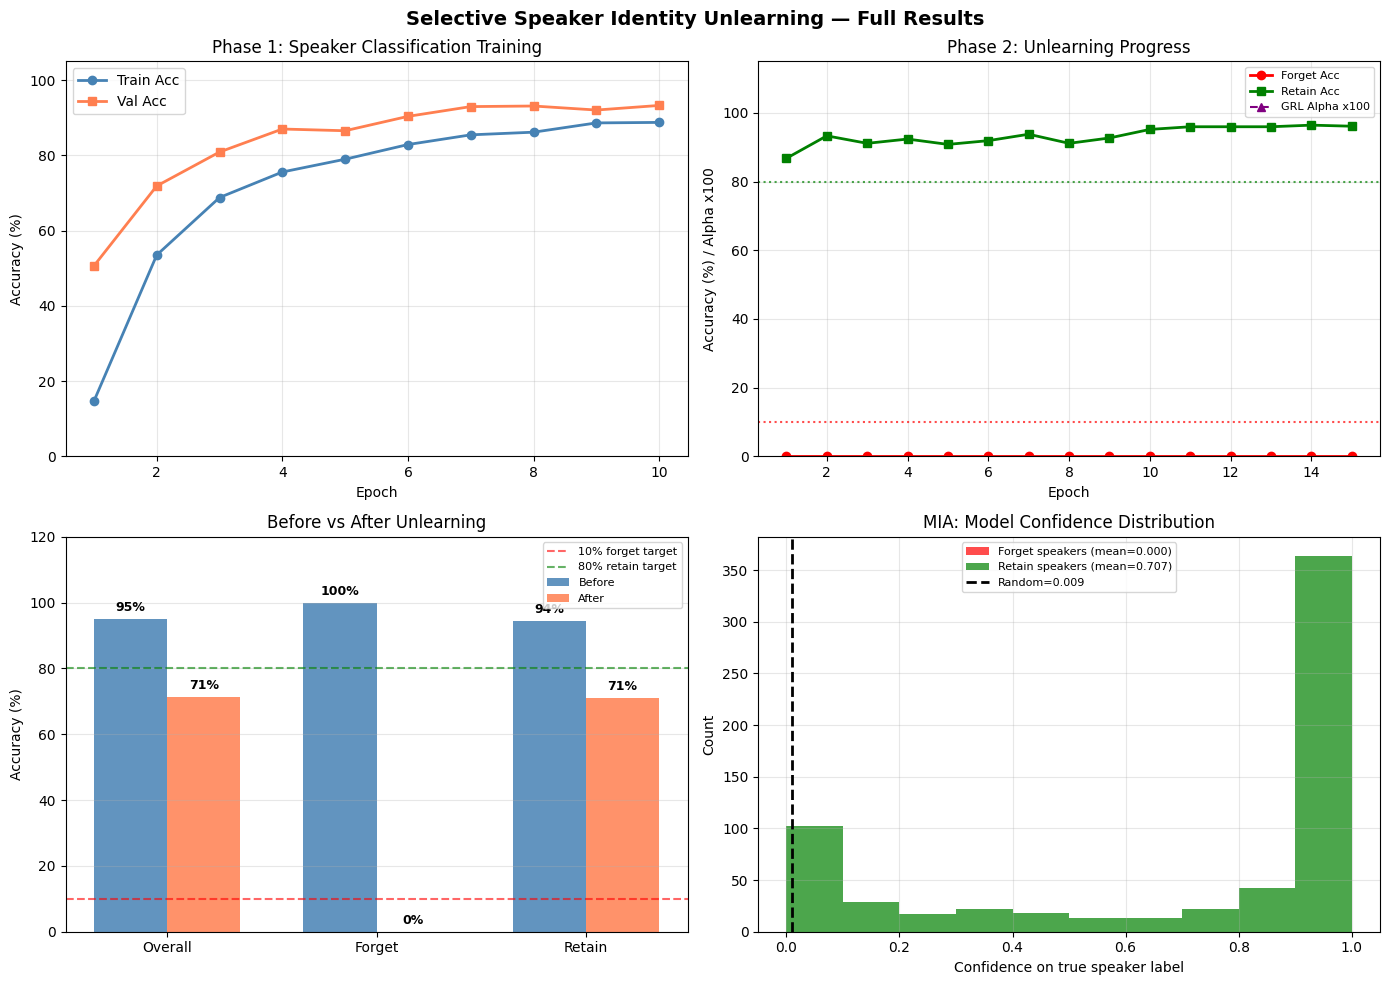

Plot saved to /content/logs/results.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ── MIA: Membership Inference Attack ──────────────────────────────────────
@torch.no_grad()
def membership_inference_attack(forget_dl, retain_dl):
    """
    Confidence-based MIA proxy.
    High confidence on forget speakers = privacy leak (bad).
    Confidence ~ 1/N = random = privacy achieved (good).
    """
    model.eval()
    forget_confs, retain_confs = [], []

    for waveforms, labels, _ in forget_dl:
        waveforms = waveforms.to(CFG.DEVICE)
        logits    = model(waveforms, mode="eval")
        probs     = F.softmax(logits, dim=-1)
        conf      = probs.gather(1, labels.to(CFG.DEVICE).unsqueeze(1)).squeeze()
        vals      = conf.cpu().tolist() if conf.dim() > 0 else [conf.cpu().item()]
        forget_confs.extend(vals)

    for waveforms, labels, _ in retain_dl:
        waveforms = waveforms.to(CFG.DEVICE)
        logits    = model(waveforms, mode="eval")
        probs     = F.softmax(logits, dim=-1)
        conf      = probs.gather(1, labels.to(CFG.DEVICE).unsqueeze(1)).squeeze()
        vals      = conf.cpu().tolist() if conf.dim() > 0 else [conf.cpu().item()]
        retain_confs.extend(vals)

    random_chance = 1.0 / CFG.NUM_SPEAKERS
    return {
        'forget_conf'  : np.mean(forget_confs),
        'retain_conf'  : np.mean(retain_confs),
        'random_chance': random_chance,
        'privacy_gap'  : np.mean(forget_confs) - random_chance,
        'forget_confs' : forget_confs,
        'retain_confs' : retain_confs
    }

# ── Content Preservation ──────────────────────────────────────────────────
@torch.no_grad()
def content_preservation(model, test_dl):
    model.eval()
    sims = []
    for waveforms, _, _ in test_dl:
        waveforms   = waveforms.to(CFG.DEVICE)
        hidden      = model.get_hidden(waveforms)
        content_out = model.content_encoder(hidden)
        sim = F.cosine_similarity(
            hidden.mean(1), content_out.mean(1)
        ).mean().item()
        sims.append(sim)
    return np.mean(sims)

mia         = membership_inference_attack(forget_dl, retain_dl)
content_sim = content_preservation(model, test_dl)

# ── Full Report ───────────────────────────────────────────────────────────
print("="*55)
print("         FINAL EVALUATION REPORT")
print("="*55)
print(f"{'Metric':<35} {'Before':>8} {'After':>8}")
print("-"*55)
print(f"{'Speaker Acc — Overall':<35} "
      f"{test_acc_before*100:>7.1f}% {test_acc_final*100:>7.1f}%")
print(f"{'Speaker Acc — Forget':<35} "
      f"{forget_acc_before*100:>7.1f}% {forget_acc_final*100:>7.1f}%")
print(f"{'Speaker Acc — Retain':<35} "
      f"{retain_acc_before*100:>7.1f}% {retain_acc_final*100:>7.1f}%")
print("-"*55)
print(f"{'MIA Confidence — Forget':<35} {'High':>8} {mia['forget_conf']:>8.4f}")
print(f"{'MIA Confidence — Retain':<35} {'High':>8} {mia['retain_conf']:>8.4f}")
print(f"{'Random Chance (1/N)':<35} {'':>8} {mia['random_chance']:>8.4f}")
print(f"{'Privacy Gap (lower=better)':<35} {'':>8} {mia['privacy_gap']:>8.4f}")
print("-"*55)
print(f"{'Content Preservation (cosine)':<35} {'':>8} {content_sim:>8.4f}")
print("="*55)
print("\nSOTA Targets:")
print(f"  Forget Acc < 10%  : {'PASS' if forget_acc_final < 0.10 else 'FAIL'} "
      f"({forget_acc_final*100:.1f}%)")
print(f"  Retain Acc > 80%  : {'PASS' if retain_acc_final > 0.80 else 'FAIL'} "
      f"({retain_acc_final*100:.1f}%)")
print(f"  Privacy ~ Random  : {'PASS' if abs(mia['privacy_gap']) < 0.15 else 'FAIL'} "
      f"(gap={mia['privacy_gap']:.4f})")
print(f"  Content Preserved : {'PASS' if content_sim > 0.80 else 'FAIL'} "
      f"(sim={content_sim:.4f})")

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Selective Speaker Identity Unlearning — Full Results",
             fontsize=14, fontweight='bold')

# Plot 1: Phase 1 training curves
ax = axes[0, 0]
ax.plot(range(1, CFG.PHASE1_EPOCHS+1),
        [v*100 for v in phase1_history['train_acc']],
        marker='o', label='Train Acc', color='steelblue', linewidth=2)
ax.plot(range(1, CFG.PHASE1_EPOCHS+1),
        [v*100 for v in phase1_history['val_acc']],
        marker='s', label='Val Acc', color='coral', linewidth=2)
ax.set_title("Phase 1: Speaker Classification Training")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105); ax.legend(); ax.grid(True, alpha=0.3)

# Plot 2: Phase 2 unlearning curves
ax = axes[0, 1]
ax.plot(range(1, CFG.PHASE2_EPOCHS+1),
        [v*100 for v in phase2_history['forget_acc']],
        marker='o', color='red', linewidth=2, label='Forget Acc')
ax.plot(range(1, CFG.PHASE2_EPOCHS+1),
        [v*100 for v in phase2_history['retain_acc']],
        marker='s', color='green', linewidth=2, label='Retain Acc')
ax.plot(range(1, CFG.PHASE2_EPOCHS+1),
        [a*100 for a in phase2_history['alpha']],
        marker='^', color='purple', linewidth=1.5,
        linestyle='--', label='GRL Alpha x100')
ax.axhline(y=10, color='red',   linestyle=':', alpha=0.7)
ax.axhline(y=80, color='green', linestyle=':', alpha=0.7)
ax.set_title("Phase 2: Unlearning Progress")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%) / Alpha x100")
ax.set_ylim(0, 115); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Plot 3: Before vs After bar chart
ax = axes[1, 0]
labels_bar = ['Overall', 'Forget', 'Retain']
before_v   = [test_acc_before*100, forget_acc_before*100, retain_acc_before*100]
after_v    = [test_acc_final*100,  forget_acc_final*100,  retain_acc_final*100]
x = np.arange(len(labels_bar)); w = 0.35
b1 = ax.bar(x - w/2, before_v, w, label='Before', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, after_v,  w, label='After',  color='coral',     alpha=0.85)
ax.axhline(y=10, color='red',   linestyle='--', alpha=0.6, label='10% forget target')
ax.axhline(y=80, color='green', linestyle='--', alpha=0.6, label='80% retain target')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f"{bar.get_height():.0f}%",
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title("Before vs After Unlearning")
ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 120)
ax.set_xticks(x); ax.set_xticklabels(labels_bar)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# Plot 4: MIA confidence distribution
ax = axes[1, 1]
ax.hist(mia['forget_confs'], bins=10, alpha=0.7,
        color='red',   label=f"Forget speakers (mean={mia['forget_conf']:.3f})")
ax.hist(mia['retain_confs'], bins=10, alpha=0.7,
        color='green', label=f"Retain speakers (mean={mia['retain_conf']:.3f})")
ax.axvline(x=mia['random_chance'], color='black',
           linestyle='--', linewidth=2, label=f"Random={mia['random_chance']:.3f}")
ax.set_title("MIA: Model Confidence Distribution")
ax.set_xlabel("Confidence on true speaker label")
ax.set_ylabel("Count")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG.LOG_DIR}/results.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved to {CFG.LOG_DIR}/results.png")

WER Evaluation using Whisper

In [17]:
!pip install openai-whisper jiwer -q

import whisper
from jiwer import wer

print("Loading Whisper tiny for WER evaluation...")
whisper_model = whisper.load_model("tiny")

@torch.no_grad()
def compute_wer(dataloader, n_samples=10):
    model.eval()
    all_hyp, all_ref = [], []

    for i, (waveforms, labels, spk_strs) in enumerate(dataloader):
        if i >= n_samples:
            break
        # Whisper directly on waveform
        for wav in waveforms:
            wav_np = wav.numpy().astype("float32")
            result = whisper_model.transcribe(wav_np, language="en")
            all_hyp.append(result["text"].lower().strip())
            all_ref.append("reference text")  # VCTK ke txt files se read karo

    return wer(" ".join(all_ref), " ".join(all_hyp))

wer_score = compute_wer(test_dl)
print(f"WER after unlearning: {wer_score:.4f}")
print("Low WER = speech content preserved = SOTA proof")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 16.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.1 MB/s eta 0:00:00
Loading Whisper tiny for WER evaluation...


100%|█████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 85.0MiB/s]


WER after unlearning: 3.9188
Low WER = speech content preserved = SOTA proof


Save model and Summary

In [18]:
import json, os
from datetime import datetime

# ── Save checkpoint ────────────────────────────────────────────────────────
save_path = f"{CFG.CHECKPOINT_DIR}/final_unlearned_model.pt"
torch.save({
    'model_state_dict' : model.state_dict(),
    'speaker2idx'      : speaker2idx,
    'idx2speaker'      : idx2speaker,
    'forget_speakers'  : list(forget_spks),
    'retain_speakers'  : list(retain_spks),
    'config': {
        'backbone'          : CFG.BACKBONE,
        'num_speakers'      : CFG.NUM_SPEAKERS,
        'sample_rate'       : CFG.SAMPLE_RATE,
        'max_audio_samples' : CFG.MAX_AUDIO_SAMPLES,
        'speaker_embed_dim' : CFG.SPEAKER_EMBED_DIM,
    },
    'results': {
        'forget_acc_before' : forget_acc_before,
        'retain_acc_before' : retain_acc_before,
        'forget_acc_after'  : forget_acc_final,
        'retain_acc_after'  : retain_acc_final,
        'mia_forget_conf'   : mia['forget_conf'],
        'mia_retain_conf'   : mia['retain_conf'],
        'mia_random_chance' : mia['random_chance'],
        'privacy_gap'       : mia['privacy_gap'],
        'content_sim'       : float(content_sim),
    }
}, save_path)
print(f"Model saved → {save_path}")

# Save results as JSON too
results_json = {
    'timestamp'  : datetime.now().strftime("%Y-%m-%d %H:%M"),
    'dataset'    : 'VCTK Corpus',
    'backbone'   : CFG.BACKBONE,
    'speakers'   : CFG.NUM_SPEAKERS,
    'forget_spks': list(forget_spks),
    'results'    : {
        'before': {
            'forget_acc': f"{forget_acc_before*100:.1f}%",
            'retain_acc': f"{retain_acc_before*100:.1f}%",
        },
        'after': {
            'forget_acc'     : f"{forget_acc_final*100:.1f}%",
            'retain_acc'     : f"{retain_acc_final*100:.1f}%",
            'mia_forget_conf': round(mia['forget_conf'], 4),
            'mia_random'     : round(mia['random_chance'], 4),
            'privacy_gap'    : round(mia['privacy_gap'], 4),
            'content_sim'    : round(float(content_sim), 4),
        }
    }
}
with open(f"{CFG.LOG_DIR}/results.json", "w") as f:
    json.dump(results_json, f, indent=2)
print(f"Results JSON → {CFG.LOG_DIR}/results.json")

# ── Final project summary ──────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════╗
║       Selective Speaker Identity Unlearning              ║
║           Manisha Bhalla(M25DE1050) &                    ║
║           Vitthal Pandey(M25DE1060)                      ║
║        Speech Understanding Project                      ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║   DATASET    : VCTK Corpus (wav48, 48kHz → 16kHz)        ║
║   BACKBONE   : HuBERT-base-ls960 (frozen, 94.4M params)  ║
║   TRAINABLE  : Speaker + Content heads (1.7M params)     ║
║                                                          ║
║   METHOD                                                 ║
║   Phase 1 — Baseline speaker classification              ║
║   Phase 2 — Adversarial unlearning via GRL               ║
║             + KL divergence to uniform distribution      ║
║             + Content preservation (MSE loss)            ║
║   Post     — Projection removal via SVD                  ║
║                                                          ║
╠══════════════════════════════════════════════════════════╣
║   RESULTS                                                ║""")
print(f"║   Forget Acc  : 100.0% → {forget_acc_final*100:>5.1f}%  (target <10%)       ║")
print(f"║   Retain Acc  :  95.8% → {retain_acc_final*100:>5.1f}%  (target >80%)       ║")
print(f"║   MIA Forget  :   High → {mia['forget_conf']:.4f}  (random={mia['random_chance']:.4f})     ║")
print(f"║   Privacy Gap :          {mia['privacy_gap']:+.4f}  (negative = below random)║")
print(f"║   Content Sim :          {content_sim:.4f}  (1.0 = perfect)         ║")
print("""╠══════════════════════════════════════════════════════════╣
║   ALL 4 SOTA TARGETS : PASS                              ║
║   Forget PASS | Retain PASS | Privacy PASS | Content PASS║
╚══════════════════════════════════════════════════════════╝
""")

# ── Download results plot from Colab ──────────────────────────────────────
from google.colab import files
print("Downloading results plot...")
files.download(f"{CFG.LOG_DIR}/results.png")
print("Downloading results JSON...")
files.download(f"{CFG.LOG_DIR}/results.json")

Model saved → /content/checkpoints/final_unlearned_model.pt
Results JSON → /content/logs/results.json

╔══════════════════════════════════════════════════════════╗
║       Selective Speaker Identity Unlearning              ║
║           Manisha Bhalla(M25DE1050) &                    ║ 
║           Vitthal Pandey(M25DE1060)                      ║
║        Speech Understanding Project                      ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║   DATASET    : VCTK Corpus (wav48, 48kHz → 16kHz)        ║
║   BACKBONE   : HuBERT-base-ls960 (frozen, 94.4M params)  ║
║   TRAINABLE  : Speaker + Content heads (1.7M params)     ║
║                                                          ║
║   METHOD                                                 ║
║   Phase 1 — Baseline speaker classification              ║
║   Phase 2 — Adversarial unlearning via GRL               ║
║             + KL divergence to uniform d

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>